# Chennai Metro Ridership Analysis (2023-2026)

## Project Overview
This project analyzes **3 years of official Chennai Metro Rail (CMRL) 
ridership data** from April 2023 to February 2026.

**Data Source:** Official CMRL open data portal (cmrl.co.in)  
**Period:** April 2023 – February 2026  
**Total Records:** 35 months

## Business Questions
- Which month had the highest ridership ever?
- How did payment behaviour shift from tokens to digital?
- What impact did Singara Chennai Card have on NCMC adoption?
- Which months show seasonal dips and why?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('ridership_payments.csv')

In [5]:
df.head()

,month,financial_year,closed_loop,closed_loop_pct,qr_tickets,qr_pct,ncmc,ncmc_pct,total
0,Apr,2023-24,4377813,65.15,2339724,34.82,1973,0.03,6719510
1,May,2023-24,4617409,63.26,2676546,36.67,5138,0.07,7299093
2,Jun,2023-24,4873031,65.90,2515727,34.02,5938,0.08,7394696
3,Jul,2023-24,5189442,62.87,2910875,35.26,154244,1.87,8254561
4,Aug,2023-24,5089362,59.25,3105583,36.15,395267,4.60,8590212


In [10]:
print("Shape of the Data",df.shape)
print("\n")
df.info()

Shape of the Data (35, 9)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   month            35 non-null     object 
 1   financial_year   35 non-null     object 
 2   closed_loop      35 non-null     int64  
 3   closed_loop_pct  35 non-null     float64
 4   qr_tickets       35 non-null     int64  
 5   qr_pct           35 non-null     float64
 6   ncmc             35 non-null     int64  
 7   ncmc_pct         35 non-null     float64
 8   total            35 non-null     int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 2.6+ KB


In [11]:
df.describe()

,closed_loop,closed_loop_pct,qr_tickets,qr_pct,ncmc,ncmc_pct,total
count,3.500000e+01,35.000000,3.500000e+01,35.000000,3.500000e+01,35.000000,3.500000e+01
mean,2.538455e+06,30.409714,3.800885e+06,42.990857,2.448293e+06,26.599429,8.787634e+06
std,1.783055e+06,22.408826,6.381685e+05,4.177439,1.813584e+06,18.768504,7.820228e+05
min,3.820500e+04,0.400000,2.339724e+06,34.020000,1.973000e+03,0.030000,6.719510e+06
25%,6.140015e+05,6.610000,3.441119e+06,40.545000,8.053465e+05,9.755000,8.427728e+06
50%,3.113865e+06,33.560000,3.774277e+06,43.460000,2.050699e+06,22.530000,8.699359e+06
75%,3.878376e+06,45.670000,4.219836e+06,45.655000,4.328017e+06,48.025000,9.303942e+06
max,5.189442e+06,65.900000,4.834104e+06,49.600000,5.196904e+06,52.210000,1.046873e+07


In [16]:
highest=df.loc[df['total'].idxmax()]
highest

month                   Jul
financial_year      2025-26
closed_loop          652808
closed_loop_pct        6.24
qr_tickets          4651897
qr_pct                44.44
ncmc                5164027
ncmc_pct              49.33
total              10468732
Name: 27, dtype: object

In [17]:
lowest=df.loc[df['total'].idxmin()]
lowest

month                  Apr
financial_year     2023-24
closed_loop        4377813
closed_loop_pct      65.15
qr_tickets         2339724
qr_pct               34.82
ncmc                  1973
ncmc_pct              0.03
total              6719510
Name: 0, dtype: object

In [29]:
print("Highest Ridership Month")
print(f"Month:{highest['month']}\nYear:{highest['financial_year']}\nTotal:{highest['total']:,}")

Highest Ridership Month
Month:Jul
Year:2025-26
Total:10,468,732


In [24]:
print("Lowest Ridership Month")
print(f"Month:{lowest['month']}\nYear:{lowest['financial_year']}\nTotal:{lowest['total']:,}")

Lowest Ridership Month
Month:Apr
Year:2023-24
Total:6,719,510


In [34]:
yearly=df.groupby('financial_year')['total'].sum().reset_index()
yearly.columns = ['financial_year', 'total_riders']
yearly['total_riders_millions'] = (yearly['total_riders'] / 1000000).round(2)
print(yearly)

,financial_year,total_riders,total_riders_millions
0,2023-24,97137553,97.14
1,2024-25,106008387,106.01
2,2025-26,104421234,104.42


## Monthly Ridership Trend
Visualizing total ridership month by month to identify growth patterns, 
seasonal dips, and overall trajectory of Chennai Metro usage.

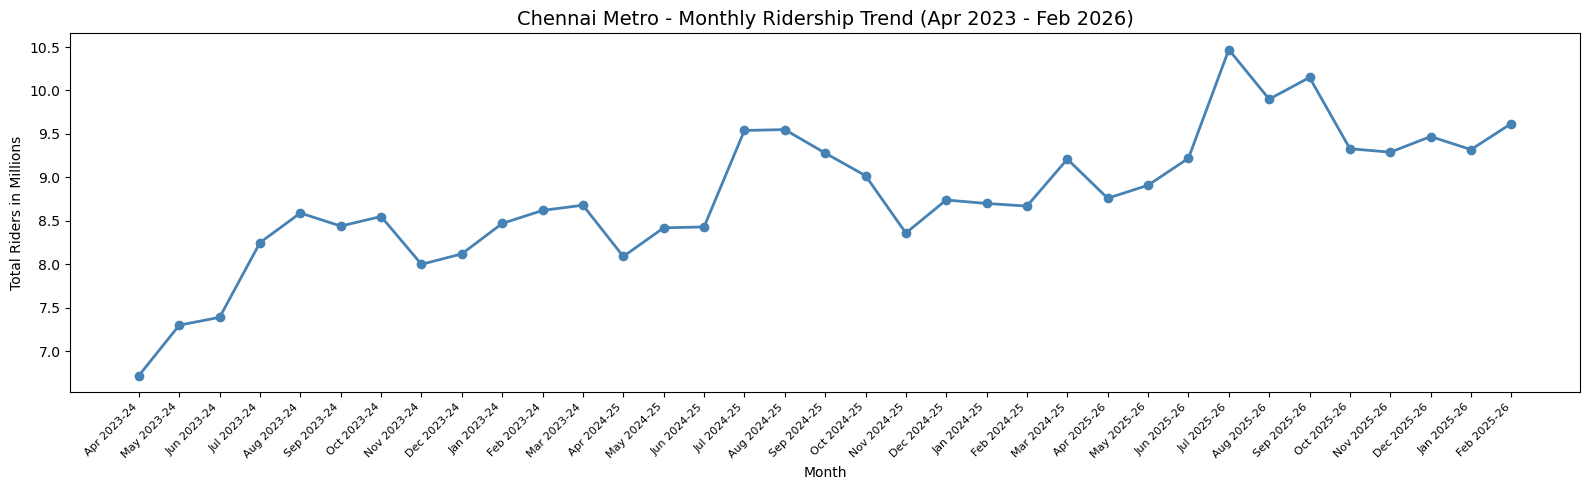

In [37]:
df['month_year'] = df['month'] + ' ' + df['financial_year']
df['total_millions'] = (df['total'] / 1000000).round(2)
plt.figure(figsize=(16, 5))
plt.plot(df['month_year'], df['total_millions'], marker='o', color='steelblue', linewidth=2)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Chennai Metro - Monthly Ridership Trend (Apr 2023 - Feb 2026)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Riders in Millions')
plt.tight_layout()
plt.show()

### 💡 Insight
Ridership grew **55% in 2 years** — from 6.7M in April 2023 
to 10.4M in July 2025, showing strong metro adoption in Chennai.

**Seasonal dip observed every August** — likely due to Chennai's 
monsoon season reducing daily commuter movement.

## Payment Method Shift
Tracking how riders pay for their journeys — from physical tokens (Closed Loop) 
to QR codes and NCMC smart cards. This is the core story of this project.

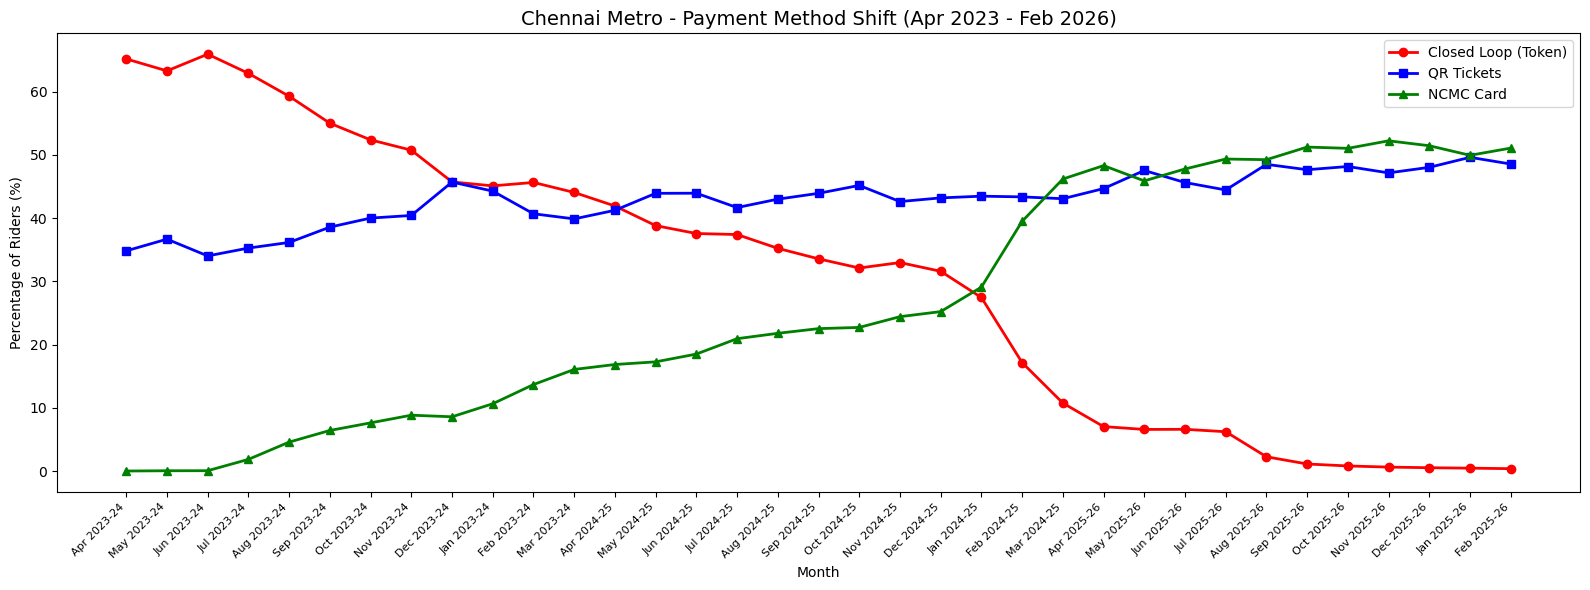

In [38]:
df['month_year'] = df['month'] + ' ' + df['financial_year']
plt.figure(figsize=(16, 6))

plt.plot(df['month_year'], df['closed_loop_pct'], 
         marker='o', label='Closed Loop (Token)', color='red', linewidth=2)
plt.plot(df['month_year'], df['qr_pct'], 
         marker='s', label='QR Tickets', color='blue', linewidth=2)
plt.plot(df['month_year'], df['ncmc_pct'], 
         marker='^', label='NCMC Card', color='green', linewidth=2)

plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Chennai Metro - Payment Method Shift (Apr 2023 - Feb 2026)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Percentage of Riders (%)')
plt.legend()
plt.tight_layout()
plt.show()

### 💡 Insight
Two clear **crossover points** visible:
- **Late 2023** — QR tickets overtook Closed Loop tokens
- **Feb 2025** — NCMC cards overtook Closed Loop tokens

Closed Loop payments **collapsed from 65% to 0.40%** in just 3 years — 
one of the fastest behavioral shifts in Indian public transport history.

## Monthly Payment Mix
Stacked bar chart showing the proportion of each payment method per month — 
revealing how rapidly digital payments have taken over.

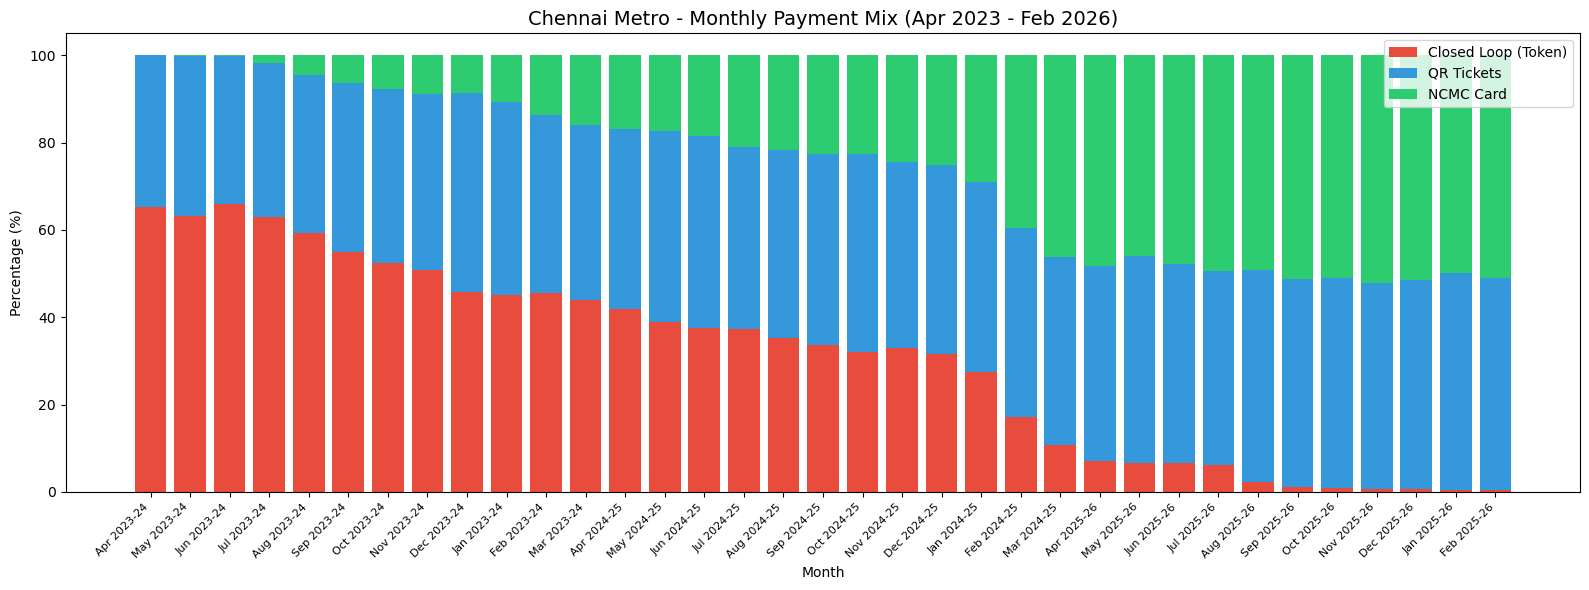

In [39]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.bar(df['month_year'], df['closed_loop_pct'], 
       label='Closed Loop (Token)', color='#e74c3c')
ax.bar(df['month_year'], df['qr_pct'], 
       bottom=df['closed_loop_pct'], 
       label='QR Tickets', color='#3498db')
ax.bar(df['month_year'], df['ncmc_pct'], 
       bottom=df['closed_loop_pct'] + df['qr_pct'], 
       label='NCMC Card', color='#2ecc71')

plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Chennai Metro - Monthly Payment Mix (Apr 2023 - Feb 2026)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Percentage (%)')
plt.legend()
plt.tight_layout()
plt.show()

### 💡 Insight
The stacked bars clearly show the **gradual disappearance of red** 
(Closed Loop) from 2023 to 2026 — replaced entirely by green (NCMC) 
and blue (QR) payments.

## Yearly Ridership Comparison
Comparing total ridership across all three financial years to measure 
year-on-year growth of Chennai Metro.

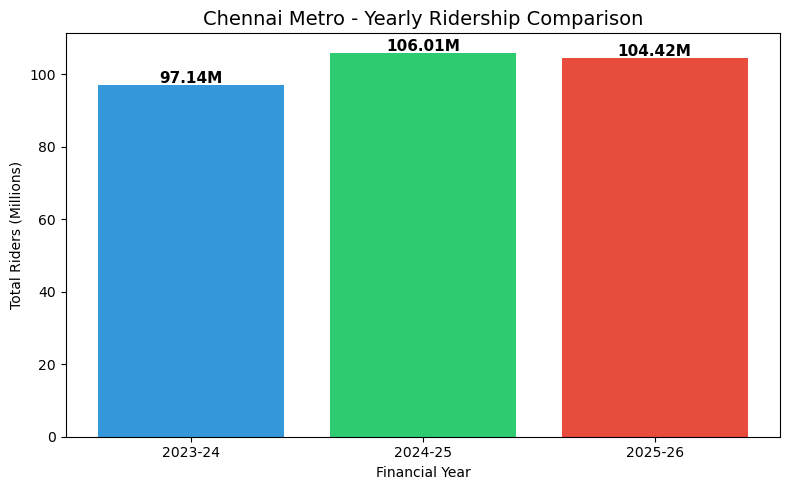

In [40]:
plt.figure(figsize=(8, 5))
bars = plt.bar(yearly['financial_year'], 
               yearly['total_riders_millions'],
               color=['#3498db', '#2ecc71', '#e74c3c'])

for bar, val in zip(bars, yearly['total_riders_millions']):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.5,
             f'{val}M', ha='center', fontsize=11, fontweight='bold')

plt.title('Chennai Metro - Yearly Ridership Comparison', fontsize=14)
plt.xlabel('Financial Year')
plt.ylabel('Total Riders (Millions)')
plt.tight_layout()
plt.show()

### 💡 Insight
**2024-25 recorded the highest yearly ridership at 106M riders.**

Note: 2025-26 shows 104M but is an **incomplete year** 
(only 11 months of data available). At current pace, 
2025-26 is on track to surpass 2024-25.

## NCMC Card Adoption Growth
Focused view on NCMC smart card growth — with the Singara Chennai Card 
launch marked as a key turning point in adoption.

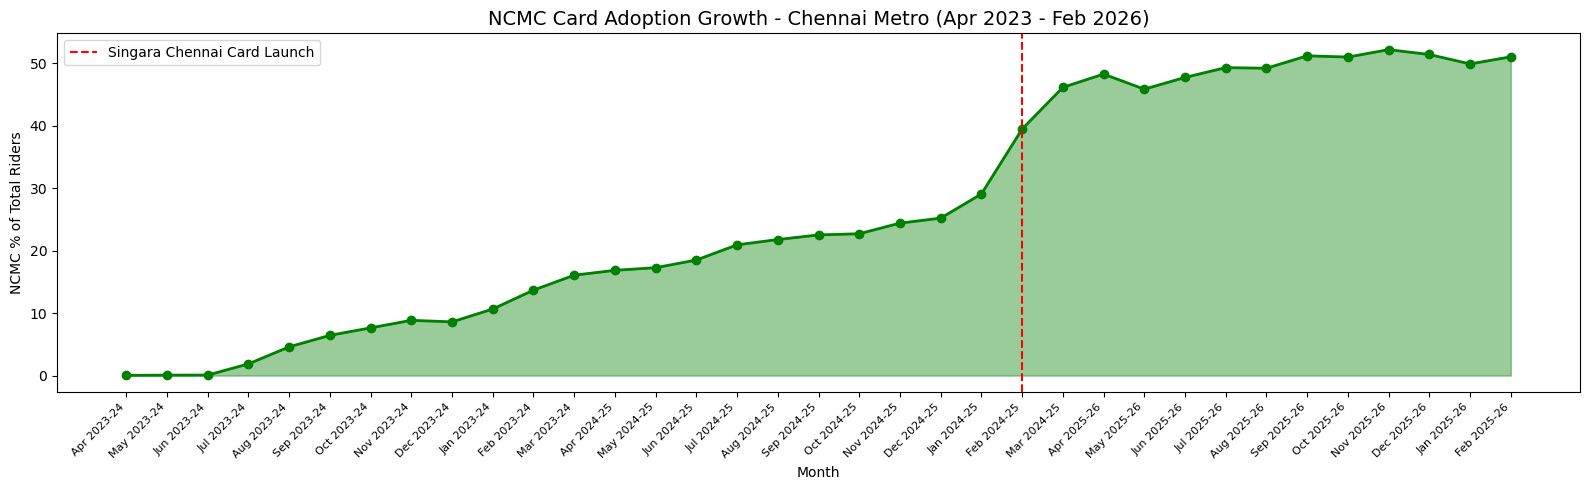

In [41]:
plt.figure(figsize=(16, 5))
plt.fill_between(df['month_year'], df['ncmc_pct'], 
                 alpha=0.4, color='green')
plt.plot(df['month_year'], df['ncmc_pct'], 
         color='green', linewidth=2, marker='o')

plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('NCMC Card Adoption Growth - Chennai Metro (Apr 2023 - Feb 2026)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('NCMC % of Total Riders')
plt.axvline(x='Feb 2024-25', color='red', 
            linestyle='--', label='Singara Chennai Card Launch')
plt.legend()
plt.tight_layout()
plt.show()

### 💡 Insight
The red dotted line marks the **Singara Chennai Card launch (Feb 2025)**.

NCMC adoption **surged from 29% to 46% in a single month** — 
the steepest growth in the entire dataset. This shows that 
a single policy decision can completely transform user behavior.

---

## 🔍 Final Summary — Key Findings

| # | Insight | Impact |
|---|---------|--------|
| 1 | Ridership grew 55% in 2 years | Strong metro adoption |
| 2 | Closed Loop collapsed 65% → 0.40% | Complete digital shift |
| 3 | Singara Chennai Card caused 17% NCMC surge | Policy drove behavior |
| 4 | April always lowest ridership | Summer holiday effect |
| 5 | August dips every year | Monsoon effect |
| 6 | NCMC crossed 50% in Oct 2025 | Digital payments now dominant |

## Data Limitations
- 2025-26 is incomplete — only 11 months available
- Station-wise data not available — analysis is network-level only
- Payment data doesn't distinguish between new vs returning NCMC users

## Tools Used
- **Python** — pandas, matplotlib, seaborn
- **MySQL** — data querying
- **Power BI** — interactive dashboard

---
*Data Source: Official CMRL open data portal*